正在读取数据...
绘图完成：Weight_Analysis_1x3.pdf


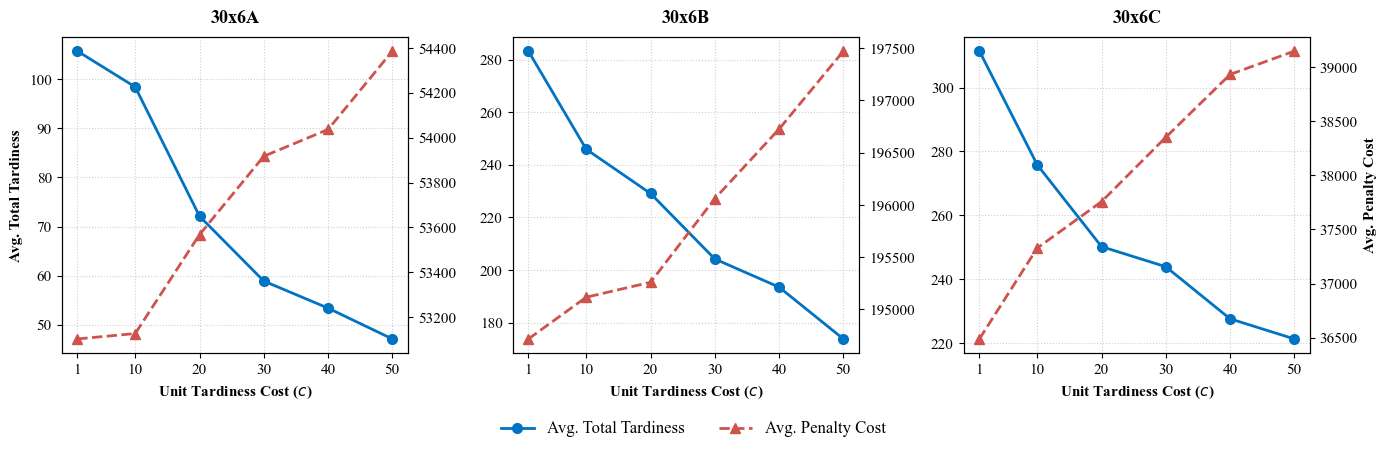

In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

weights = [1, 10, 20, 30, 40, 50]

instance_names = [
    'TDSP30_6_30_6_M',
    'TDSP30_6_30_6_MD',
    'TDSP30_6_30_6_X'
]

file_suffix = "_solSim.txt"

subplot_titles = ["30x6A", "30x6B", "30x6C"]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 11

def parse_results(instance, weight):
    folder_name = f"WSensiti{weight}"
    file_name = f"{instance}{file_suffix}"
    file_path = os.path.join(folder_name, file_name)

    if not os.path.exists(file_path):
        print(f"错误: 找不到文件 {file_path}")
        return None, None

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
            t_matches = re.findall(r"Tardiness\s+([\d\.]+)", content)
            p_matches = re.findall(r"Penalty\s+([\d\.]+)", content)

            if t_matches and p_matches:
                t_floats = [float(x) for x in t_matches]
                p_floats = [float(x) for x in p_matches]
                return float(np.mean(t_floats)), float(np.mean(p_floats))
            else:
                return None, None
    except Exception as e:
        print(f"读取错误 {file_path}: {e}")
        return None, None

# ================= 3. 读取数据 =================
data_store = {name: {'w': [], 'tardiness': [], 'penalty': []} for name in instance_names}

print("正在读取数据...")
for instance in instance_names:
    for w in weights:
        t, p = parse_results(instance, w)
        if t is not None:
            data_store[instance]['w'].append(w)
            data_store[instance]['tardiness'].append(t)
            data_store[instance]['penalty'].append(p)


fig, axes = plt.subplots(1, 3, figsize=(14, 4.5)) 
axes_flat = axes.flatten()

color_t = '#0073C2FF'  # 蓝色 (Tardiness)
color_p = '#CD534CFF'  # 红色 (Penalty)
marker_t = 'o'
marker_p = '^'

lines_for_legend = []
labels_for_legend = []

for i, instance in enumerate(instance_names):
    ax1 = axes_flat[i]
    title_name = subplot_titles[i]

    if not data_store[instance]['w']:
        ax1.text(0.5, 0.5, 'Data Not Found', ha='center', va='center')
        ax1.set_title(title_name, fontweight='bold')
        continue

    x = data_store[instance]['w']
    y1 = data_store[instance]['tardiness']
    y2 = data_store[instance]['penalty']

    # --- 左轴：Tardiness ---
    line1, = ax1.plot(
        x, y1, color=color_t, marker=marker_t, linestyle='-',
        linewidth=2, markersize=7, label='Avg. Total Tardiness'
    )
    
    # 只有最左边的图显示左轴标题
    if i == 0:
        ax1.set_ylabel('Avg. Total Tardiness', color='black', fontweight='bold')
    
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_xticks(weights)
    ax1.set_xlabel('Unit Tardiness Cost ($c$)', fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- 右轴：Penalty ---
    ax2 = ax1.twinx()
    line2, = ax2.plot(
        x, y2, color=color_p, marker=marker_p, linestyle='--',
        linewidth=2, markersize=7, label='Avg. Penalty Cost'
    )
    
    # 只有最右边的图显示右轴标题
    if i == 2:
        ax2.set_ylabel('Avg. Penalty Cost', color='black', fontweight='bold')
    
    ax2.tick_params(axis='y', labelcolor='black')

    # 子图标题
    ax1.set_title(title_name, fontsize=13, pad=10, fontweight='bold')

    # 提取图例句柄
    if i == 0:
        lines_for_legend = [line1, line2]
        labels_for_legend = [l.get_label() for l in lines_for_legend]


fig.legend(
    lines_for_legend, labels_for_legend,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02), 
    ncol=2,
    fontsize=12,
    frameon=False
)

plt.tight_layout()

plt.subplots_adjust(bottom=0.2)

fig.savefig('Weight_Analysis_1x3.pdf', format='pdf', bbox_inches='tight')
print("绘图完成：Weight_Analysis_1x3.pdf")
plt.show()